# Financial PIT features vs forward-return labels

Runs the local EDA script for snapshot `2026-06-19` and displays generated outputs.

## `feature_label` 한글 설명

`corr_table.csv`와 heatmap의 `feature_label`은 `feat_fin_pit`의 재무 feature를 사람이 읽기 쉽게 줄인 이름입니다.

| feature | feature_label | 한글 설명 | 해석 메모 |
| --- | --- | --- | --- |
| `fin_roa` | ROA | 총자산순이익률. 순이익을 총자산으로 나눈 수익성 지표입니다. | 자산 대비 이익 창출력이 높을수록 값이 커집니다. |
| `fin_roe` | ROE | 자기자본순이익률. 순이익을 자기자본으로 나눈 수익성 지표입니다. | 자본잠식 또는 낮은 자기자본 구간에서는 왜곡될 수 있습니다. |
| `fin_debt_to_equity` | Debt/Equity | 부채비율. 총부채를 자기자본으로 나눈 재무 레버리지 지표입니다. | 값이 높을수록 부채 의존도가 큽니다. 자기자본이 0 이하이면 null 처리됩니다. |
| `fin_equity_ratio` | Equity Ratio | 자기자본비율. 자기자본을 총자산으로 나눈 안정성 지표입니다. | 값이 높을수록 자산 중 자기자본 비중이 큽니다. |
| `fin_ocf_to_assets` | OCF/Assets | 영업현금흐름/총자산. 영업현금흐름을 총자산으로 나눈 현금 창출력 지표입니다. | 회계상 이익보다 현금 기반 수익성을 보는 지표입니다. |
| `fin_cash_ratio` | Cash/Assets | 현금성자산/총자산. 현금 및 현금성자산을 총자산으로 나눈 유동성 지표입니다. | 값이 높을수록 보유 현금 비중이 큽니다. 업종별 차이가 클 수 있습니다. |
| `fin_asset_turnover` | Asset Turnover | 총자산회전율. 매출을 총자산으로 나눈 효율성 지표입니다. | 자산을 얼마나 매출로 전환하는지 봅니다. 금융업 등 업종 차이에 주의합니다. |
| `fin_operating_margin` | Operating Margin | 영업이익률. 영업이익을 매출로 나눈 수익성 지표입니다. | 매출 대비 본업 수익성을 봅니다. 매출이 작거나 음수인 경우 해석이 불안정합니다. |
| `fin_is_negative_equity` | Negative Equity | 자본잠식 여부. 자기자본이 0 이하인 경우 `1`로 표시되는 플래그입니다. | 비율 지표가 아니라 위험/상태 플래그입니다. |
| `fin_has_fs` | Has FS | 재무제표 feature 존재 여부. 해당 시점에 PIT 기준 재무제표가 붙어 있으면 `1`입니다. | 신호라기보다 데이터 가용성 플래그입니다. 상관이 높아도 해석에 주의합니다. |


In [1]:
from pathlib import Path
import subprocess

cwd = Path.cwd().resolve()
repo = next(p for p in [cwd, *cwd.parents] if (p / 'pyproject.toml').exists())
analysis_dir = repo / 'research' / 'analysis' / 'fin_vs_price_corr'
report_dir = repo / 'reports' / 'analysis' / 'fin_vs_price_corr' / '20260627'
report_dir

PosixPath('/Users/whishaw/wss_p/stock_data_collector/reports/analysis/fin_vs_price_corr/20260627')

In [2]:
subprocess.run([
    'uv', 'run', 'python', str(analysis_dir / 'run_fin_price_correlation.py'),
    '--snapshot-date', '2026-06-19',
    '--report-date', '20260627',
], cwd=repo, check=True)

Wrote /Users/whishaw/wss_p/stock_data_collector/reports/analysis/fin_vs_price_corr/20260627
Top features for raw_label_20d: fin_cash_ratio, fin_equity_ratio, fin_debt_to_equity


CompletedProcess(args=['uv', 'run', 'python', '/Users/whishaw/wss_p/stock_data_collector/research/analysis/fin_vs_price_corr/run_fin_price_correlation.py', '--snapshot-date', '2026-06-19', '--report-date', '20260627'], returncode=0)

# fin_vs_price_corr summary

- snapshot_date: 2026-06-19
- source: local_mydb
- base rows: 5,024,637
- date range: 2015-04-14 ~ 2026-05-20
- tickers: 2,606
- primary_target: raw_label_20d

## Conclusion

Primary target `raw_label_20d` 기준 최상위 단일 재무지표는 `fin_cash_ratio`이며 Spearman=-0.0340, Pearson=-0.0002입니다. 상위 3개 지표(fin_cash_ratio, fin_equity_ratio, fin_debt_to_equity)의 단순 선형회귀 R^2 최대값은 0.000016로, 현재 스냅샷에서는 재무비율 단독의 선형 설명력은 매우 약합니다. 분위수/그룹 안정성 CSV를 함께 보며 특정 구간에서만 나타나는 신호인지 확인해야 합니다.

## Outputs

- `corr_table.csv`
- `corr_heatmap.png`
- `scatter_top3.png`
- `quintile_returns.csv`
- `quintile_returns.png`
- `regression_summary.csv`
- `group_stability.csv`
- `winsor_thresholds.csv`


,feature,feature_label,target,n,pearson,spearman
35,fin_cash_ratio,Cash/Assets,raw_label_60d,4927445,-0.001824,-0.043207
59,fin_has_fs,Has FS,raw_label_60d,4927445,0.002122,-0.040443
23,fin_equity_ratio,Equity Ratio,raw_label_60d,4927445,-0.002847,-0.039163
26,fin_ocf_to_assets,OCF/Assets,fwd_ret_60d,4927445,0.036721,0.038095
34,fin_cash_ratio,Cash/Assets,raw_label_20d,5024637,-0.000163,-0.033984
17,fin_debt_to_equity,Debt/Equity,raw_label_60d,4927445,0.008410,-0.033897
58,fin_has_fs,Has FS,raw_label_20d,5024637,0.003123,-0.032541
22,fin_equity_ratio,Equity Ratio,raw_label_20d,5024637,0.000385,-0.030022
16,fin_debt_to_equity,Debt/Equity,raw_label_20d,5024637,0.004022,-0.028080
29,fin_ocf_to_assets,OCF/Assets,raw_label_60d,4927445,0.000739,-0.025254


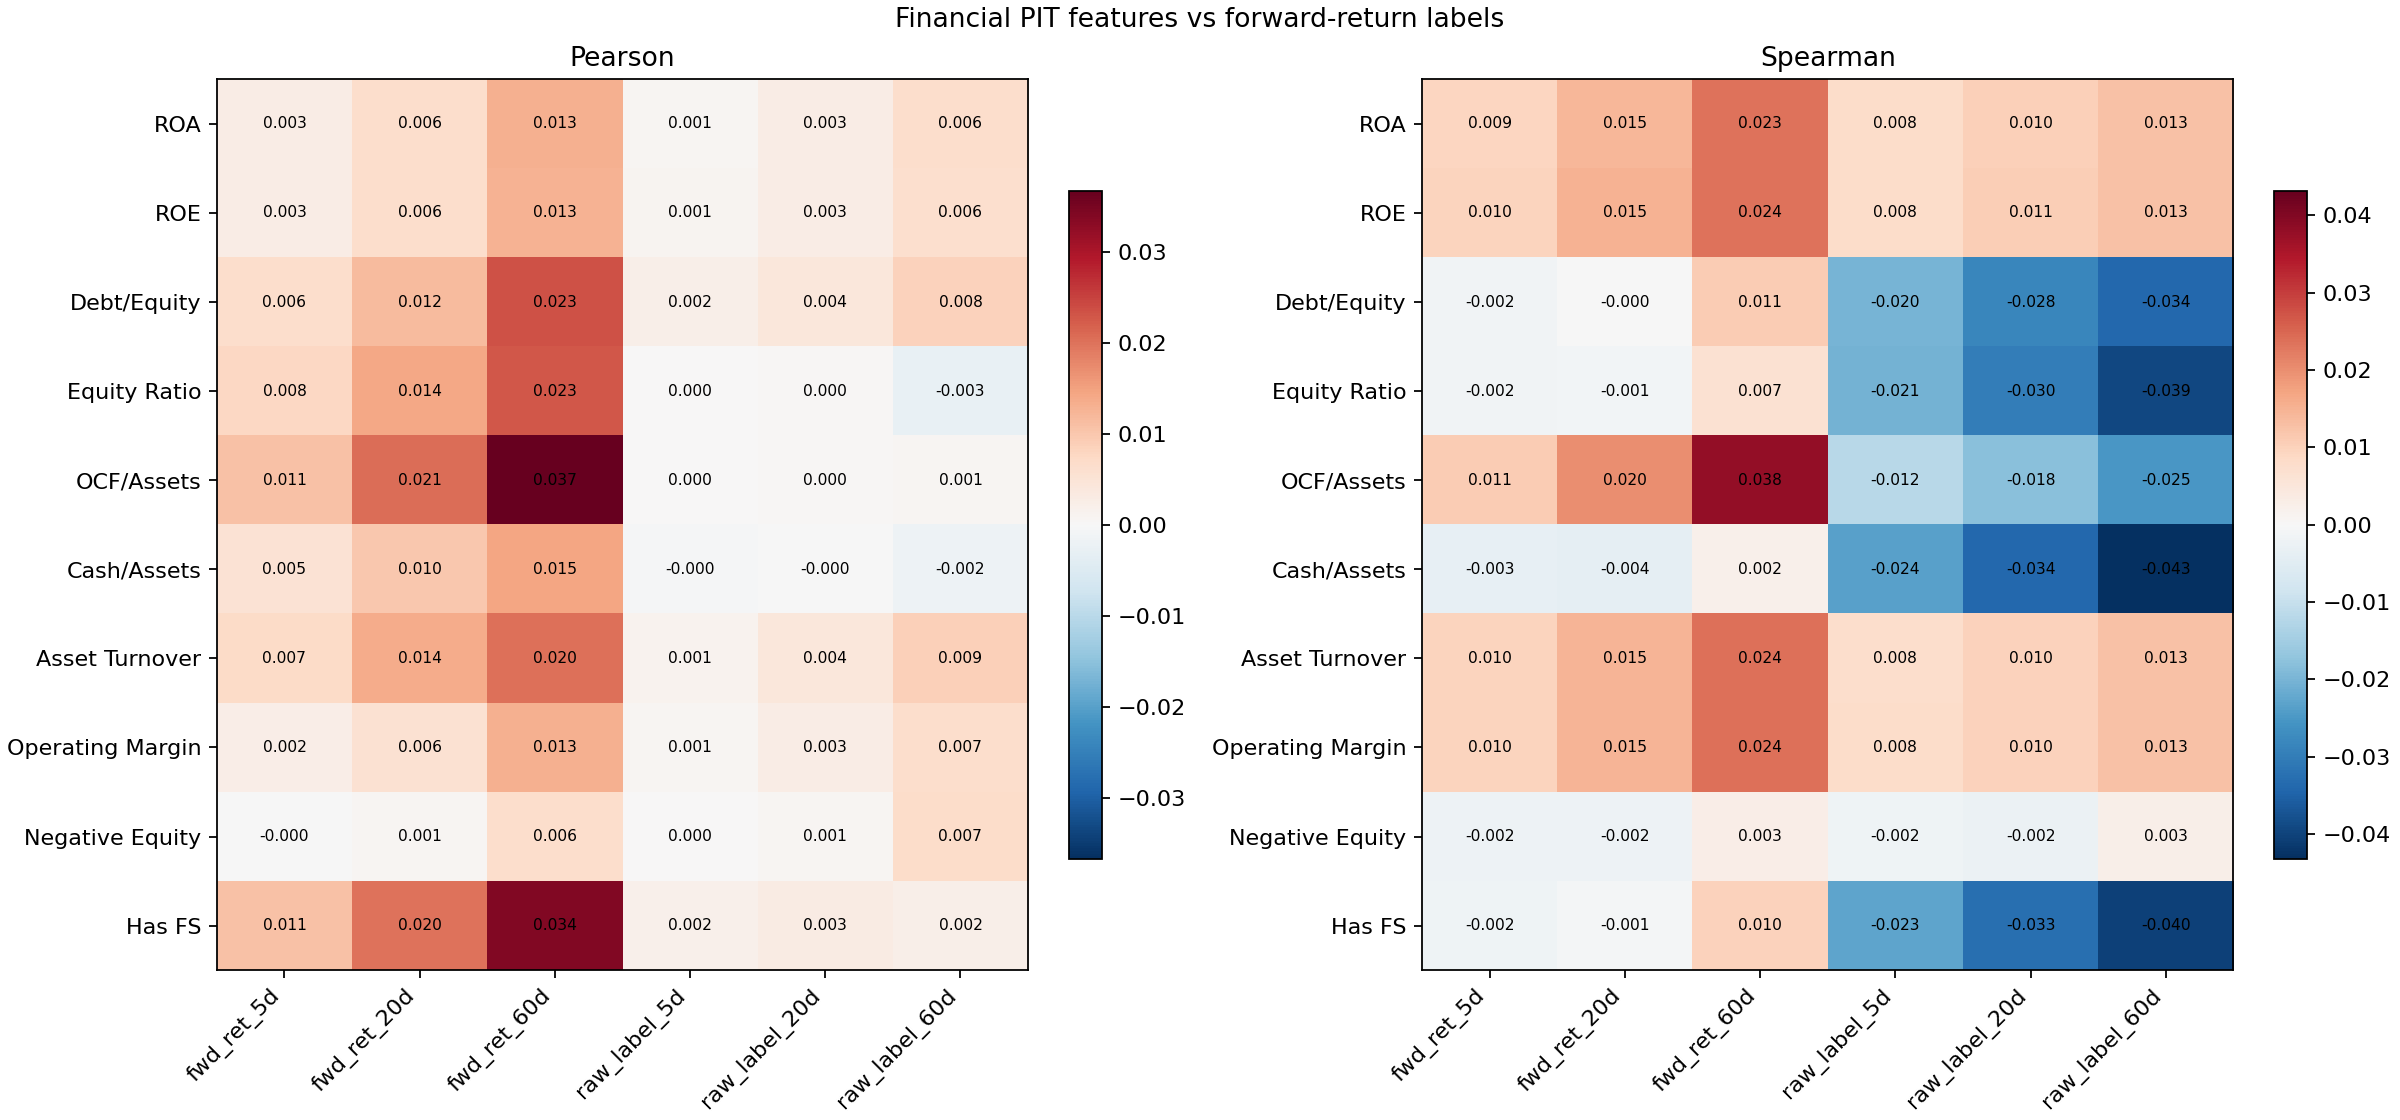

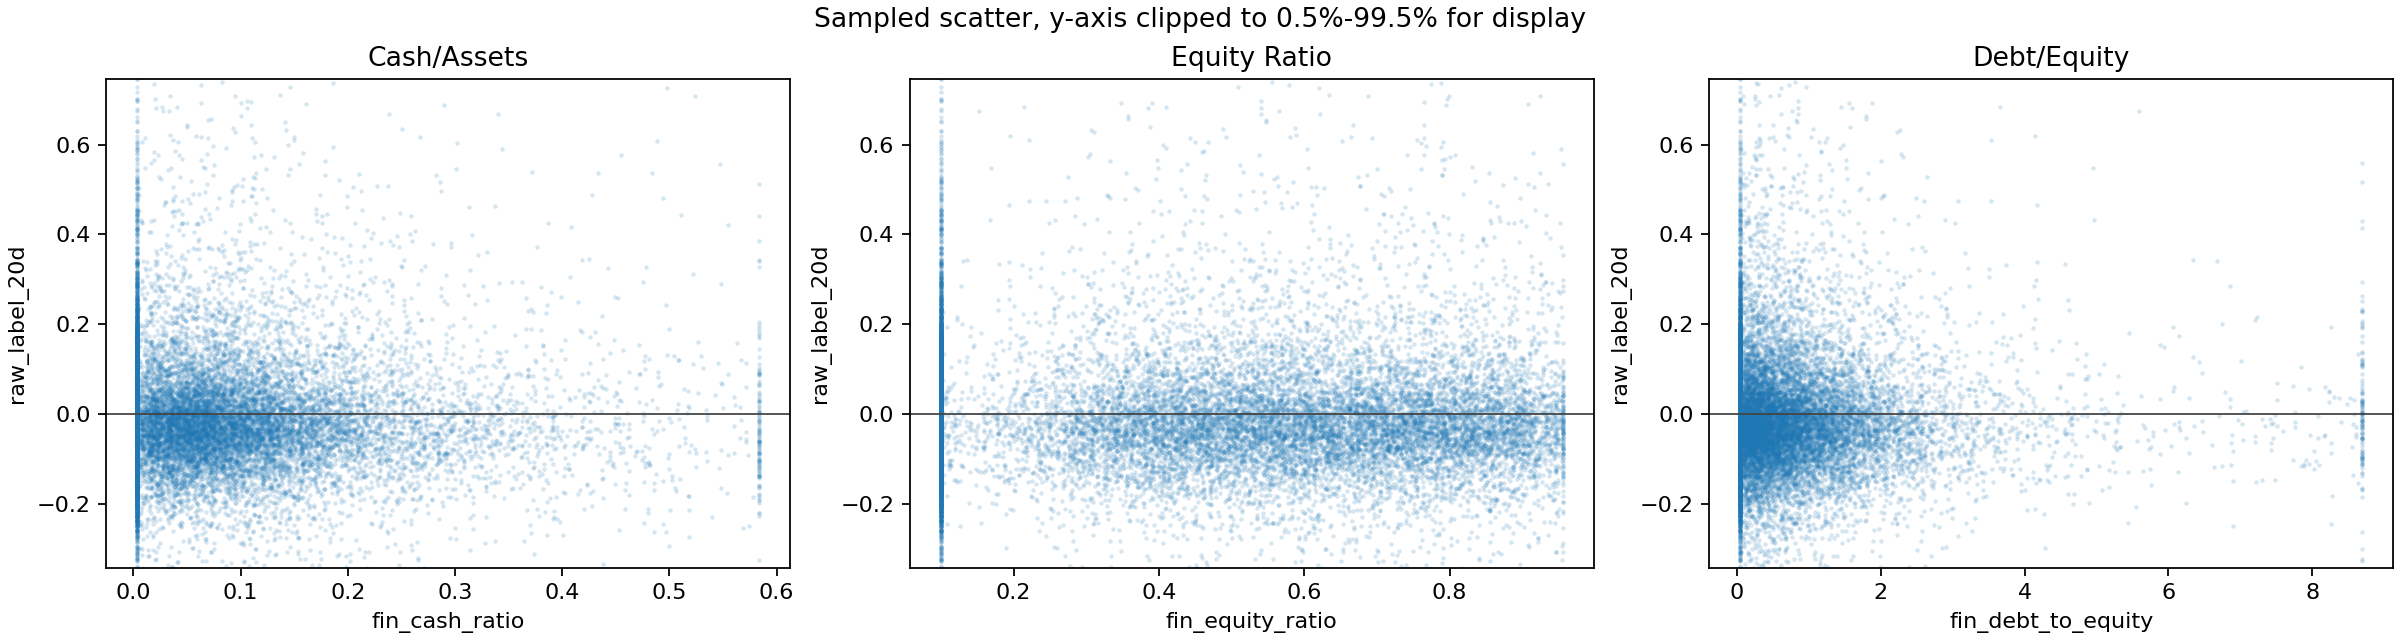

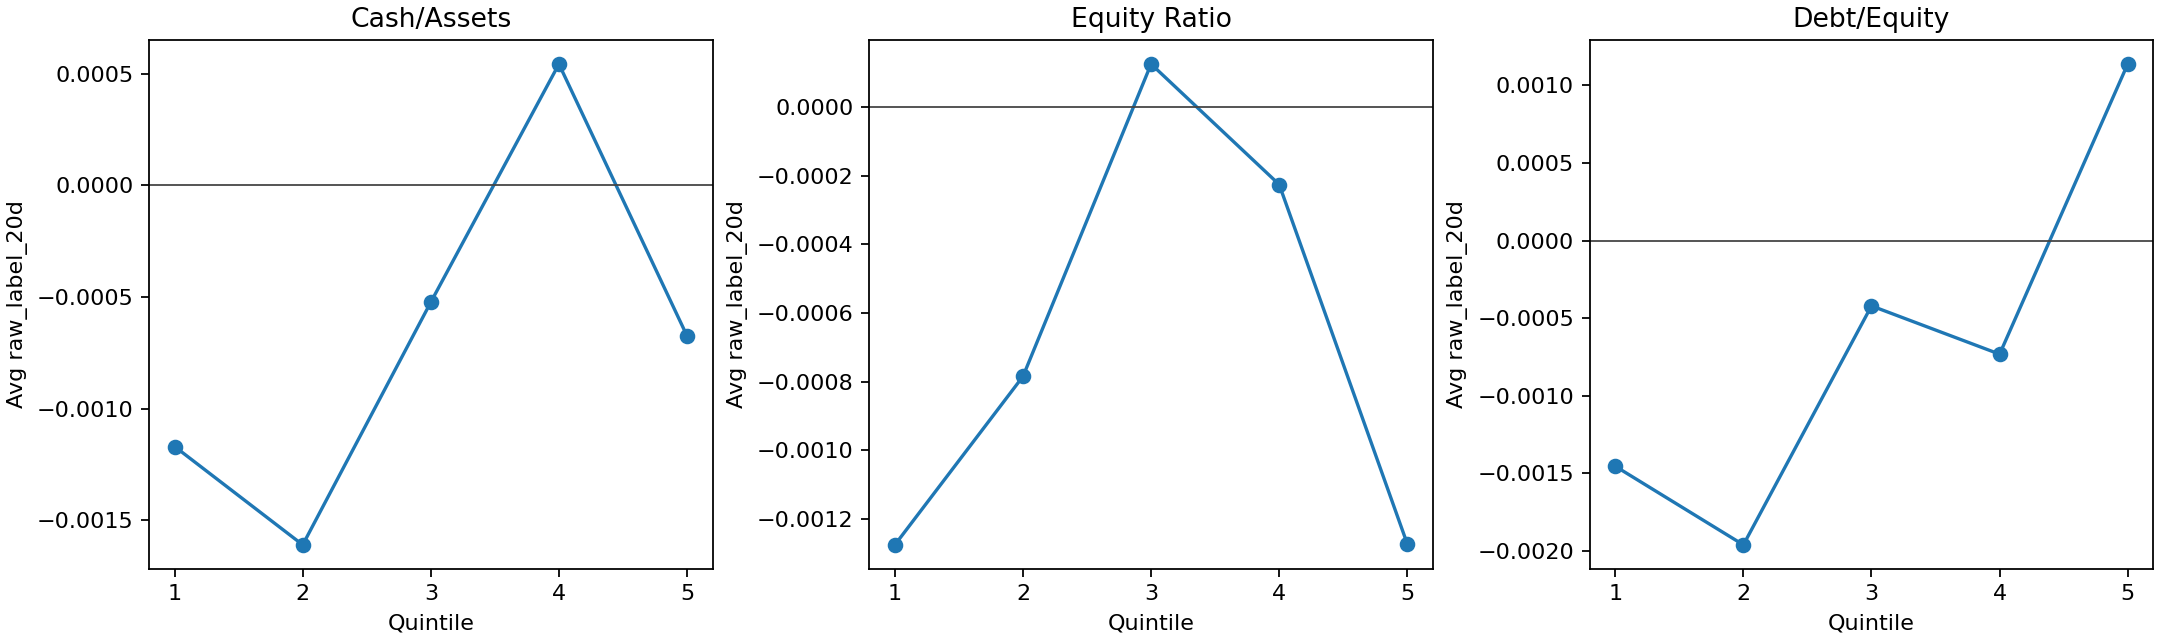

In [3]:
import pandas as pd
from IPython.display import Image, display, Markdown

display(Markdown((report_dir / 'analysis_summary.md').read_text(encoding='utf-8')))
display(pd.read_csv(report_dir / 'corr_table.csv').sort_values('spearman', key=lambda s: s.abs(), ascending=False).head(15))
display(Image(filename=str(report_dir / 'corr_heatmap.png')))
display(Image(filename=str(report_dir / 'scatter_top3.png')))
display(Image(filename=str(report_dir / 'quintile_returns.png')))